In [110]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt

In [64]:
IN = '../data/raw'
OUT = '../data/python_master'

df = pd.read_csv(f"{IN}/planning_applications/PS2_data_-_open_data_table__202512_.csv",
                  encoding="cp1252", skiprows=2)

# list_cols = df.columns.to_list()
# for col in list_cols:
#     if "Total granted" in col:
#         print(col)

# Columns we need: Total granted; major total (all), Total granted; minor total(all)

df['Total Granted'] = df["Total granted; major total (all)"]

qs = df['Quarter'].str.replace(" ", "")
df['Quarter'] = pd.PeriodIndex(qs, freq='Q')

# Groupping by quarter then summing for England total- may revisit file later on for regional analysis
df_eng = df.groupby('Quarter')['Total Granted'].sum().reset_index()

df_eng.to_csv(f"{OUT}/planning/plan_granted.csv")

/tmp/ipykernel_30756/3833559299.py:4: DtypeWarning: Columns (0: Total decisions; major dwellings (all), 1: Total granted; major dwellings (all), 2: Total refused; major dwellings (all), 3: Total decided within 8 weeks; major dwellings (excluding PAs), 4: Total decided within 8 to 13 weeks; major dwellings (excluding PAs), 5: Total decided within 13 to 16 weeks; major dwellings (excluding PAs), 6: Total decided within 16 to 26 weeks; major dwellings (excluding PAs), 7: Total decided within 26 to 52 weeks; major dwellings (excluding PAs), 8: Total decided beyond 52 weeks; major dwellings (excluding PAs), 9: Total decided within maximum time; major dwellings (excluding PAs), 10: Total decisions; major dwellings (PAs only), 11: Total decisions in time; major dwellings (PAs only), 12: Total decisions; major offices R&D light industry (all), 13: Total granted; major offices R&D light industry (all), 14: Total refused; major offices R&D light industry (all), 15: Total decided within 8 weeks; 

<Axes: xlabel='Quarter'>

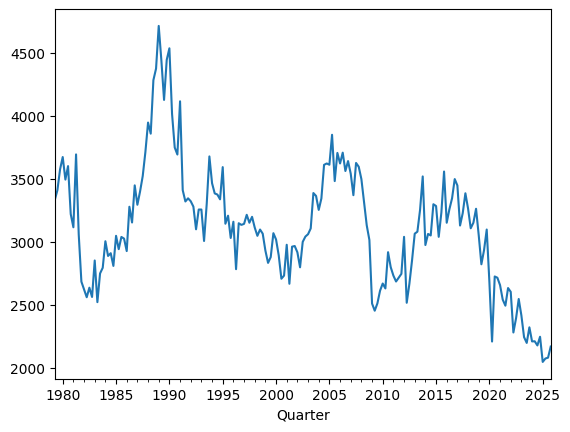

In [65]:
df_eng.set_index('Quarter')['Total Granted'].plot()

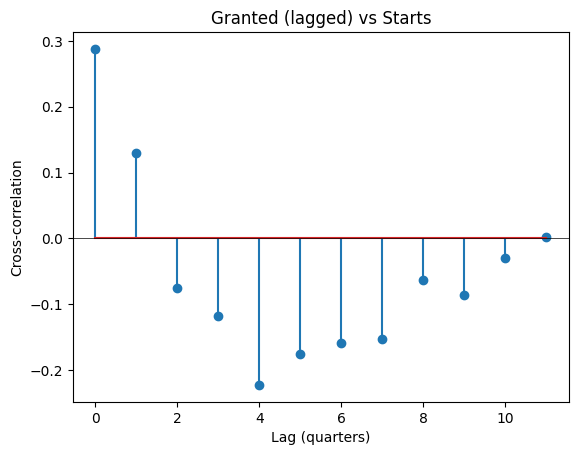

In [ ]:
df_starts = pd.read_csv(f"{OUT}/england_master.csv")

df_starts = df_starts.iloc[:,:2]

df_starts.columns = ['Quarter', 'Starts']

df_starts['Quarter'] = pd.PeriodIndex(df_starts['Quarter'], freq='Q')


df = pd.merge(df_starts, df_eng, on='Quarter')

df

# Starts was found to be trend stationary I(0), but we choose to difference so we dont compare level-diff
#  We convert total granted to I(0) by differencing adjusting for seasonality
df['Total Granted'] = df['Total Granted'].diff(4)
df['Starts'] = df['Starts'].diff(4)
df = df.dropna()

# Finding cross correlations across lags
result = ccf(df['Starts'], df['Total Granted'])

n_lags = 12
plt.stem(range(n_lags), result[:n_lags])
plt.xlabel('Lag (quarters)')
plt.ylabel('Cross-correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Granted (lagged) vs Starts')
plt.show()

# Co-movement with 0-1 quarter - we choose 1